In [ ]:
from dask.distributed import Client
from matplotlib import pyplot as plt
import xarray as xr
import timeit


In [17]:
INPUT_DIR = "/data_3/scratch/francesco/zarr_demo_pixel_chunked_small.zarr/"
# N_WORKERS = 1
N_WORKERS = 10

client = Client(
    n_workers=N_WORKERS,
    threads_per_worker=1,
    memory_limit='24GB',
    processes=True,  # Use separate processes (not threads, but this appears to create non-shared memory)
    dashboard_address=':1234'
)  # start distributed scheduler locally.
# Total cores used: 10 workers × 2 threads = 20 cores

client.gather
client.ncores
client.dashboard_link 

/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 1234 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45593 instead
  warnings.warn(


'http://127.0.0.1:45593/status'

In [18]:
ds_main = xr.open_zarr(INPUT_DIR, chunks='auto')


In [19]:
timeit.timeit(
    lambda: ds_main["ndvi"].isel(pixel = 1)[0:100].load(), 
    number = 1)



0.8941657529212534

In [20]:
timeit.timeit(
    lambda: ds_main["ndvi"].isel(pixel = slice(1,50)).load(), 
    number = 1)

1.1266902470961213

0.10774705186486244

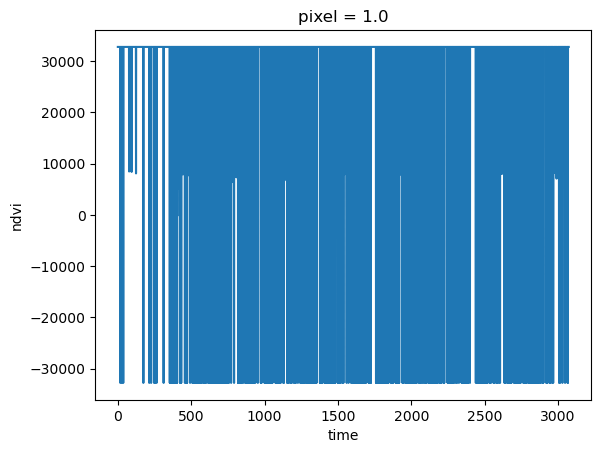

In [21]:
timeit.timeit(
    lambda: ds_main["ndvi"].isel(pixel = 1).plot(), 
    number = 1)

In [23]:
timeit.timeit(
    lambda: ds_main["ndvi"].isel(pixel = slice(0,1)).mean().compute(), 
    number = 1)

0.06269067106768489

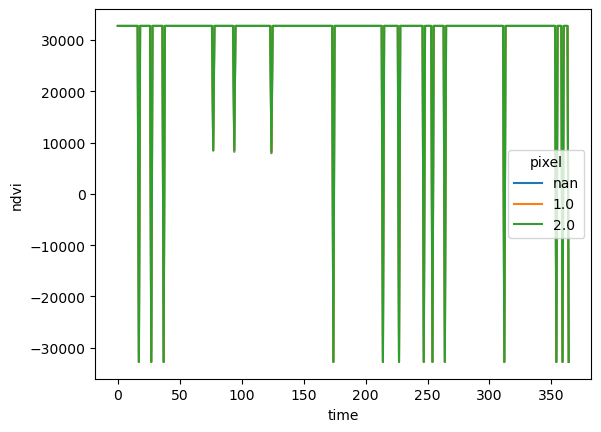

In [26]:
(ds_main["ndvi"]
    .isel(pixel = slice(0,3), time = slice(0,365))
    .plot(x = 'time', hue ='pixel'))